# FleetRL-Warehouse Quickstart

This notebook verifies the environment, renders the warehouse, trains a small Q-learning agent, and evaluates it. Use the `fleetrl` Anaconda environment.


In [4]:
import sys
from pathlib import Path

print("Python executable:")
print(sys.executable)

print("\nCurrent notebook folder:")
print(Path.cwd())

print("\nFiles in this folder:")
for item in Path.cwd().iterdir():
    print(item.name)

Python executable:
C:\Users\mazya\.conda\envs\fleetrl\python.exe

Current notebook folder:
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\notebooks

Files in this folder:
.ipynb_checkpoints
quickstart.ipynb


In [5]:
from pathlib import Path

project_root = Path.cwd().parent
artifacts_dir = project_root / "artifacts"

print("Project root:")
print(project_root)

print("\nArtifacts folder:")
print(artifacts_dir)

print("\nArtifacts folder exists:", artifacts_dir.exists())

if artifacts_dir.exists():
    print("\nFiles inside artifacts:")
    for item in artifacts_dir.iterdir():
        print("-", item.name)

Project root:
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0

Artifacts folder:
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\artifacts

Artifacts folder exists: True

Files inside artifacts:
- q_learning.csv
- q_learning.json
- sarsa.csv
- sarsa.json
- tabular_benchmark.csv
- tabular_benchmark.summary.json


In [7]:
%pip install pandas matplotlib

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.8 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.8 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.8 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.8 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.8 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.8 MB 1.6 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/9.8 MB 1.6 MB/s eta 0:00:05
   ------------ --------------------------- 3.1/9.8 MB 1.6 MB/s eta 0:00:05
   --------------- ------------------------ 3.7/9.8 MB 1.6 MB/s eta 0:00:04
   ---------------- --------------

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
q_path = project_root / "artifacts" / "q_learning.csv"

q = pd.read_csv(q_path)

print("Loaded file:", q_path)
print("Columns:", list(q.columns))
print("Number of training episodes:", len(q))

q.head()

Matplotlib is building the font cache; this may take a moment.


Loaded file: C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\artifacts\q_learning.csv
Columns: ['episode', 'reward', 'completion_rate', 'collisions', 'steps', 'epsilon']
Number of training episodes: 1500


,episode,reward,completion_rate,collisions,steps,epsilon
0,0.0,-11.40,0.0,0.0,100.0,0.995000
1,1.0,-11.68,0.0,0.0,100.0,0.990025
2,2.0,-10.08,0.0,0.0,100.0,0.985075
3,3.0,-9.24,0.0,0.0,100.0,0.980150
4,4.0,-13.68,0.0,1.0,100.0,0.975249


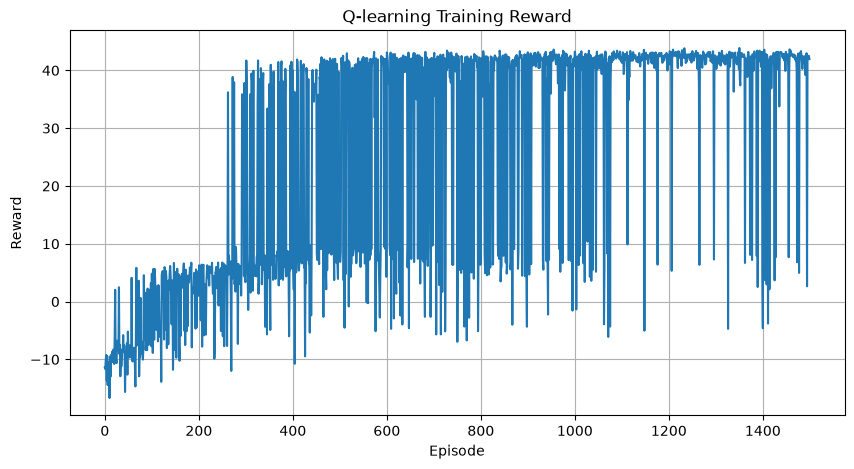

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(q["episode"], q["reward"])
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-learning Training Reward")
plt.grid(True)
plt.show()

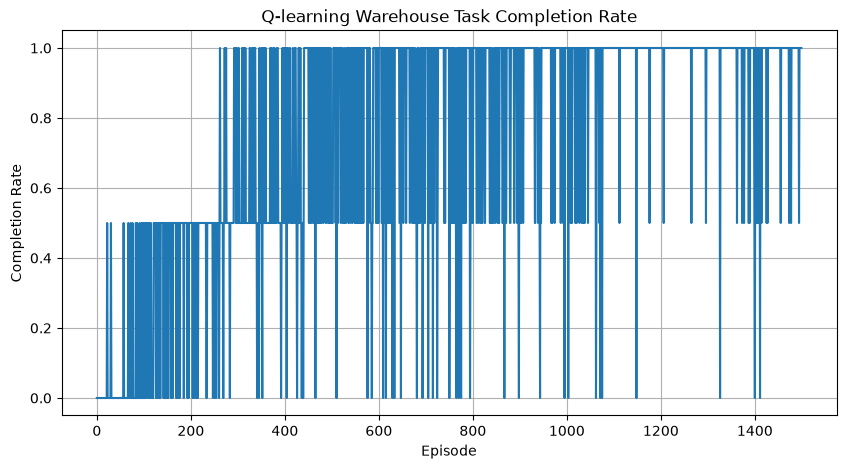

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(q["episode"], q["completion_rate"])
plt.xlabel("Episode")
plt.ylabel("Completion Rate")
plt.title("Q-learning Warehouse Task Completion Rate")
plt.grid(True)
plt.show()

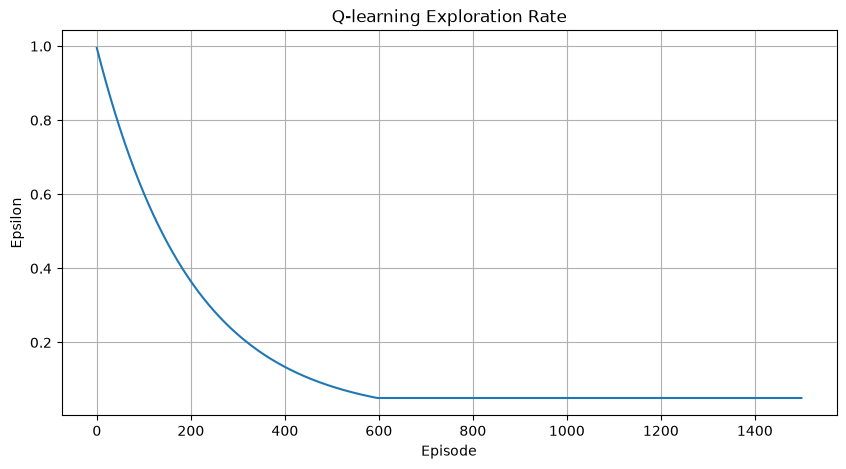

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(q["episode"], q["epsilon"])
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Q-learning Exploration Rate")
plt.grid(True)
plt.show()

In [5]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
sarsa_path = project_root / "artifacts" / "sarsa.csv"

sarsa = pd.read_csv(sarsa_path)

print("Loaded file:", sarsa_path)
print("Columns:", list(sarsa.columns))
print("Number of training episodes:", len(sarsa))

sarsa.head()

Loaded file: C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\artifacts\sarsa.csv
Columns: ['episode', 'reward', 'completion_rate', 'collisions', 'steps', 'epsilon']
Number of training episodes: 1500


,episode,reward,completion_rate,collisions,steps,epsilon
0,0.0,-11.40,0.0,0.0,100.0,0.995000
1,1.0,-11.68,0.0,0.0,100.0,0.990025
2,2.0,-10.08,0.0,0.0,100.0,0.985075
3,3.0,-9.24,0.0,0.0,100.0,0.980150
4,4.0,-13.68,0.0,1.0,100.0,0.975249


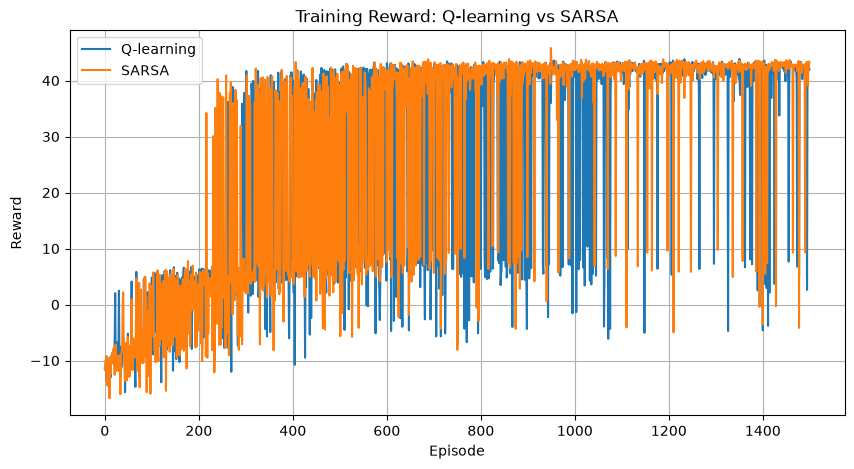

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(q["episode"], q["reward"], label="Q-learning")
plt.plot(sarsa["episode"], sarsa["reward"], label="SARSA")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward: Q-learning vs SARSA")
plt.legend()
plt.grid(True)
plt.show()

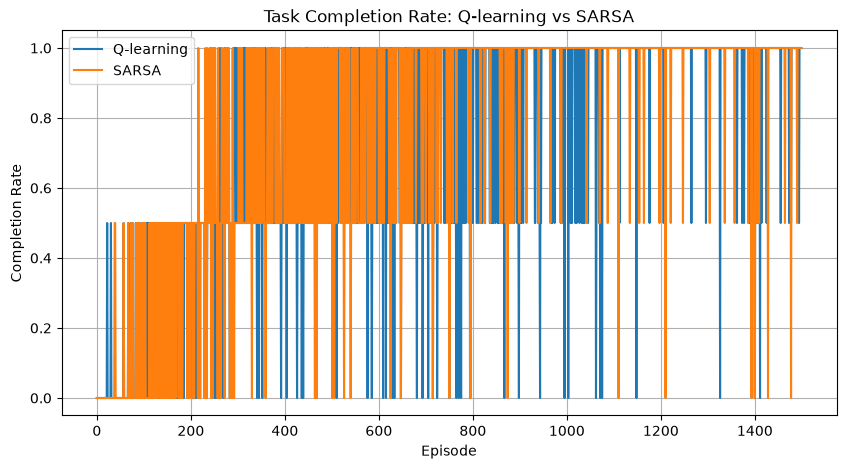

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(q["episode"], q["completion_rate"], label="Q-learning")
plt.plot(sarsa["episode"], sarsa["completion_rate"], label="SARSA")
plt.xlabel("Episode")
plt.ylabel("Completion Rate")
plt.title("Task Completion Rate: Q-learning vs SARSA")
plt.legend()
plt.grid(True)
plt.show()

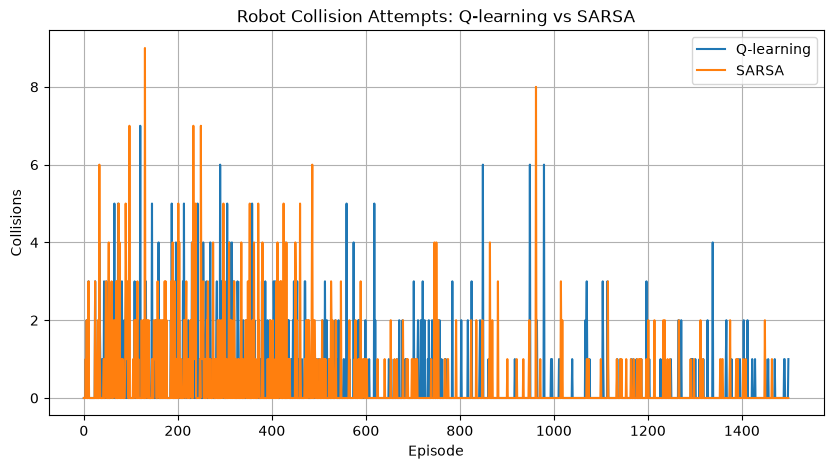

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(q["episode"], q["collisions"], label="Q-learning")
plt.plot(sarsa["episode"], sarsa["collisions"], label="SARSA")
plt.xlabel("Episode")
plt.ylabel("Collisions")
plt.title("Robot Collision Attempts: Q-learning vs SARSA")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
summary = pd.DataFrame(
    {
        "Algorithm": ["Q-learning", "SARSA"],
        "Mean reward - last 100 episodes": [
            q["reward"].tail(100).mean(),
            sarsa["reward"].tail(100).mean(),
        ],
        "Mean completion - last 100 episodes": [
            q["completion_rate"].tail(100).mean(),
            sarsa["completion_rate"].tail(100).mean(),
        ],
        "Mean collisions - last 100 episodes": [
            q["collisions"].tail(100).mean(),
            sarsa["collisions"].tail(100).mean(),
        ],
        "Mean steps - last 100 episodes": [
            q["steps"].tail(100).mean(),
            sarsa["steps"].tail(100).mean(),
        ],
    }
)

summary

,Algorithm,Mean reward - last 100 episodes,Mean completion - last 100 episodes,Mean collisions - last 100 episodes,Mean steps - last 100 episodes
0,Q-learning,37.2296,0.93,0.12,57.88
1,SARSA,39.8599,0.95,0.05,48.05


In [10]:
comparison_path = project_root / "artifacts" / "q_learning_vs_sarsa_summary.csv"

summary.to_csv(comparison_path, index=False)

print("Saved comparison table to:")
print(comparison_path)

Saved comparison table to:
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\artifacts\q_learning_vs_sarsa_summary.csv


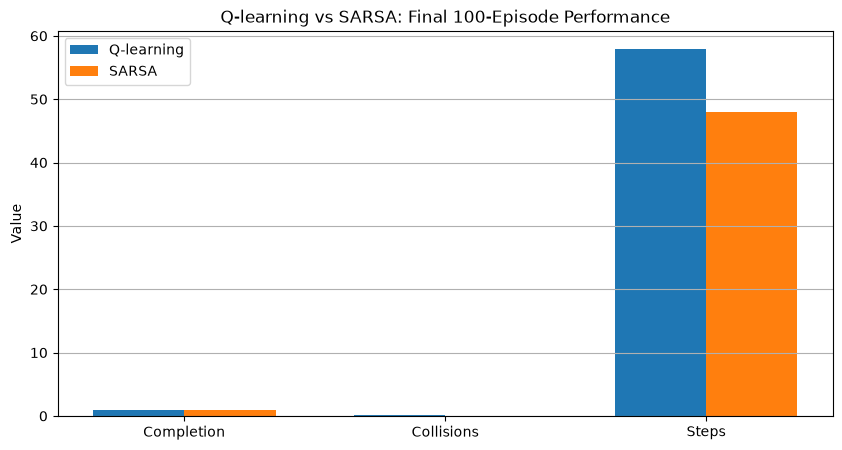

Saved figure to:
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\docs\assets\q_learning_vs_sarsa_summary.png


In [11]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = project_root / "docs" / "assets"
figures_dir.mkdir(parents=True, exist_ok=True)

metrics = ["Completion", "Collisions", "Steps"]
q_values = [
    summary.loc[summary["Algorithm"] == "Q-learning", "Mean completion - last 100 episodes"].values[0],
    summary.loc[summary["Algorithm"] == "Q-learning", "Mean collisions - last 100 episodes"].values[0],
    summary.loc[summary["Algorithm"] == "Q-learning", "Mean steps - last 100 episodes"].values[0],
]
sarsa_values = [
    summary.loc[summary["Algorithm"] == "SARSA", "Mean completion - last 100 episodes"].values[0],
    summary.loc[summary["Algorithm"] == "SARSA", "Mean collisions - last 100 episodes"].values[0],
    summary.loc[summary["Algorithm"] == "SARSA", "Mean steps - last 100 episodes"].values[0],
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width / 2 for i in x], q_values, width, label="Q-learning")
plt.bar([i + width / 2 for i in x], sarsa_values, width, label="SARSA")
plt.xticks(list(x), metrics)
plt.ylabel("Value")
plt.title("Q-learning vs SARSA: Final 100-Episode Performance")
plt.legend()
plt.grid(axis="y")

output_path = figures_dir / "q_learning_vs_sarsa_summary.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(output_path)

In [12]:
from pathlib import Path

comparison_image = project_root / "docs" / "assets" / "q_learning_vs_sarsa_summary.png"

print("Comparison image exists:", comparison_image.exists())
print("Image path:", comparison_image)

if comparison_image.exists():
    print("Image size in bytes:", comparison_image.stat().st_size)

Comparison image exists: True
Image path: C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\docs\assets\q_learning_vs_sarsa_summary.png
Image size in bytes: 74005


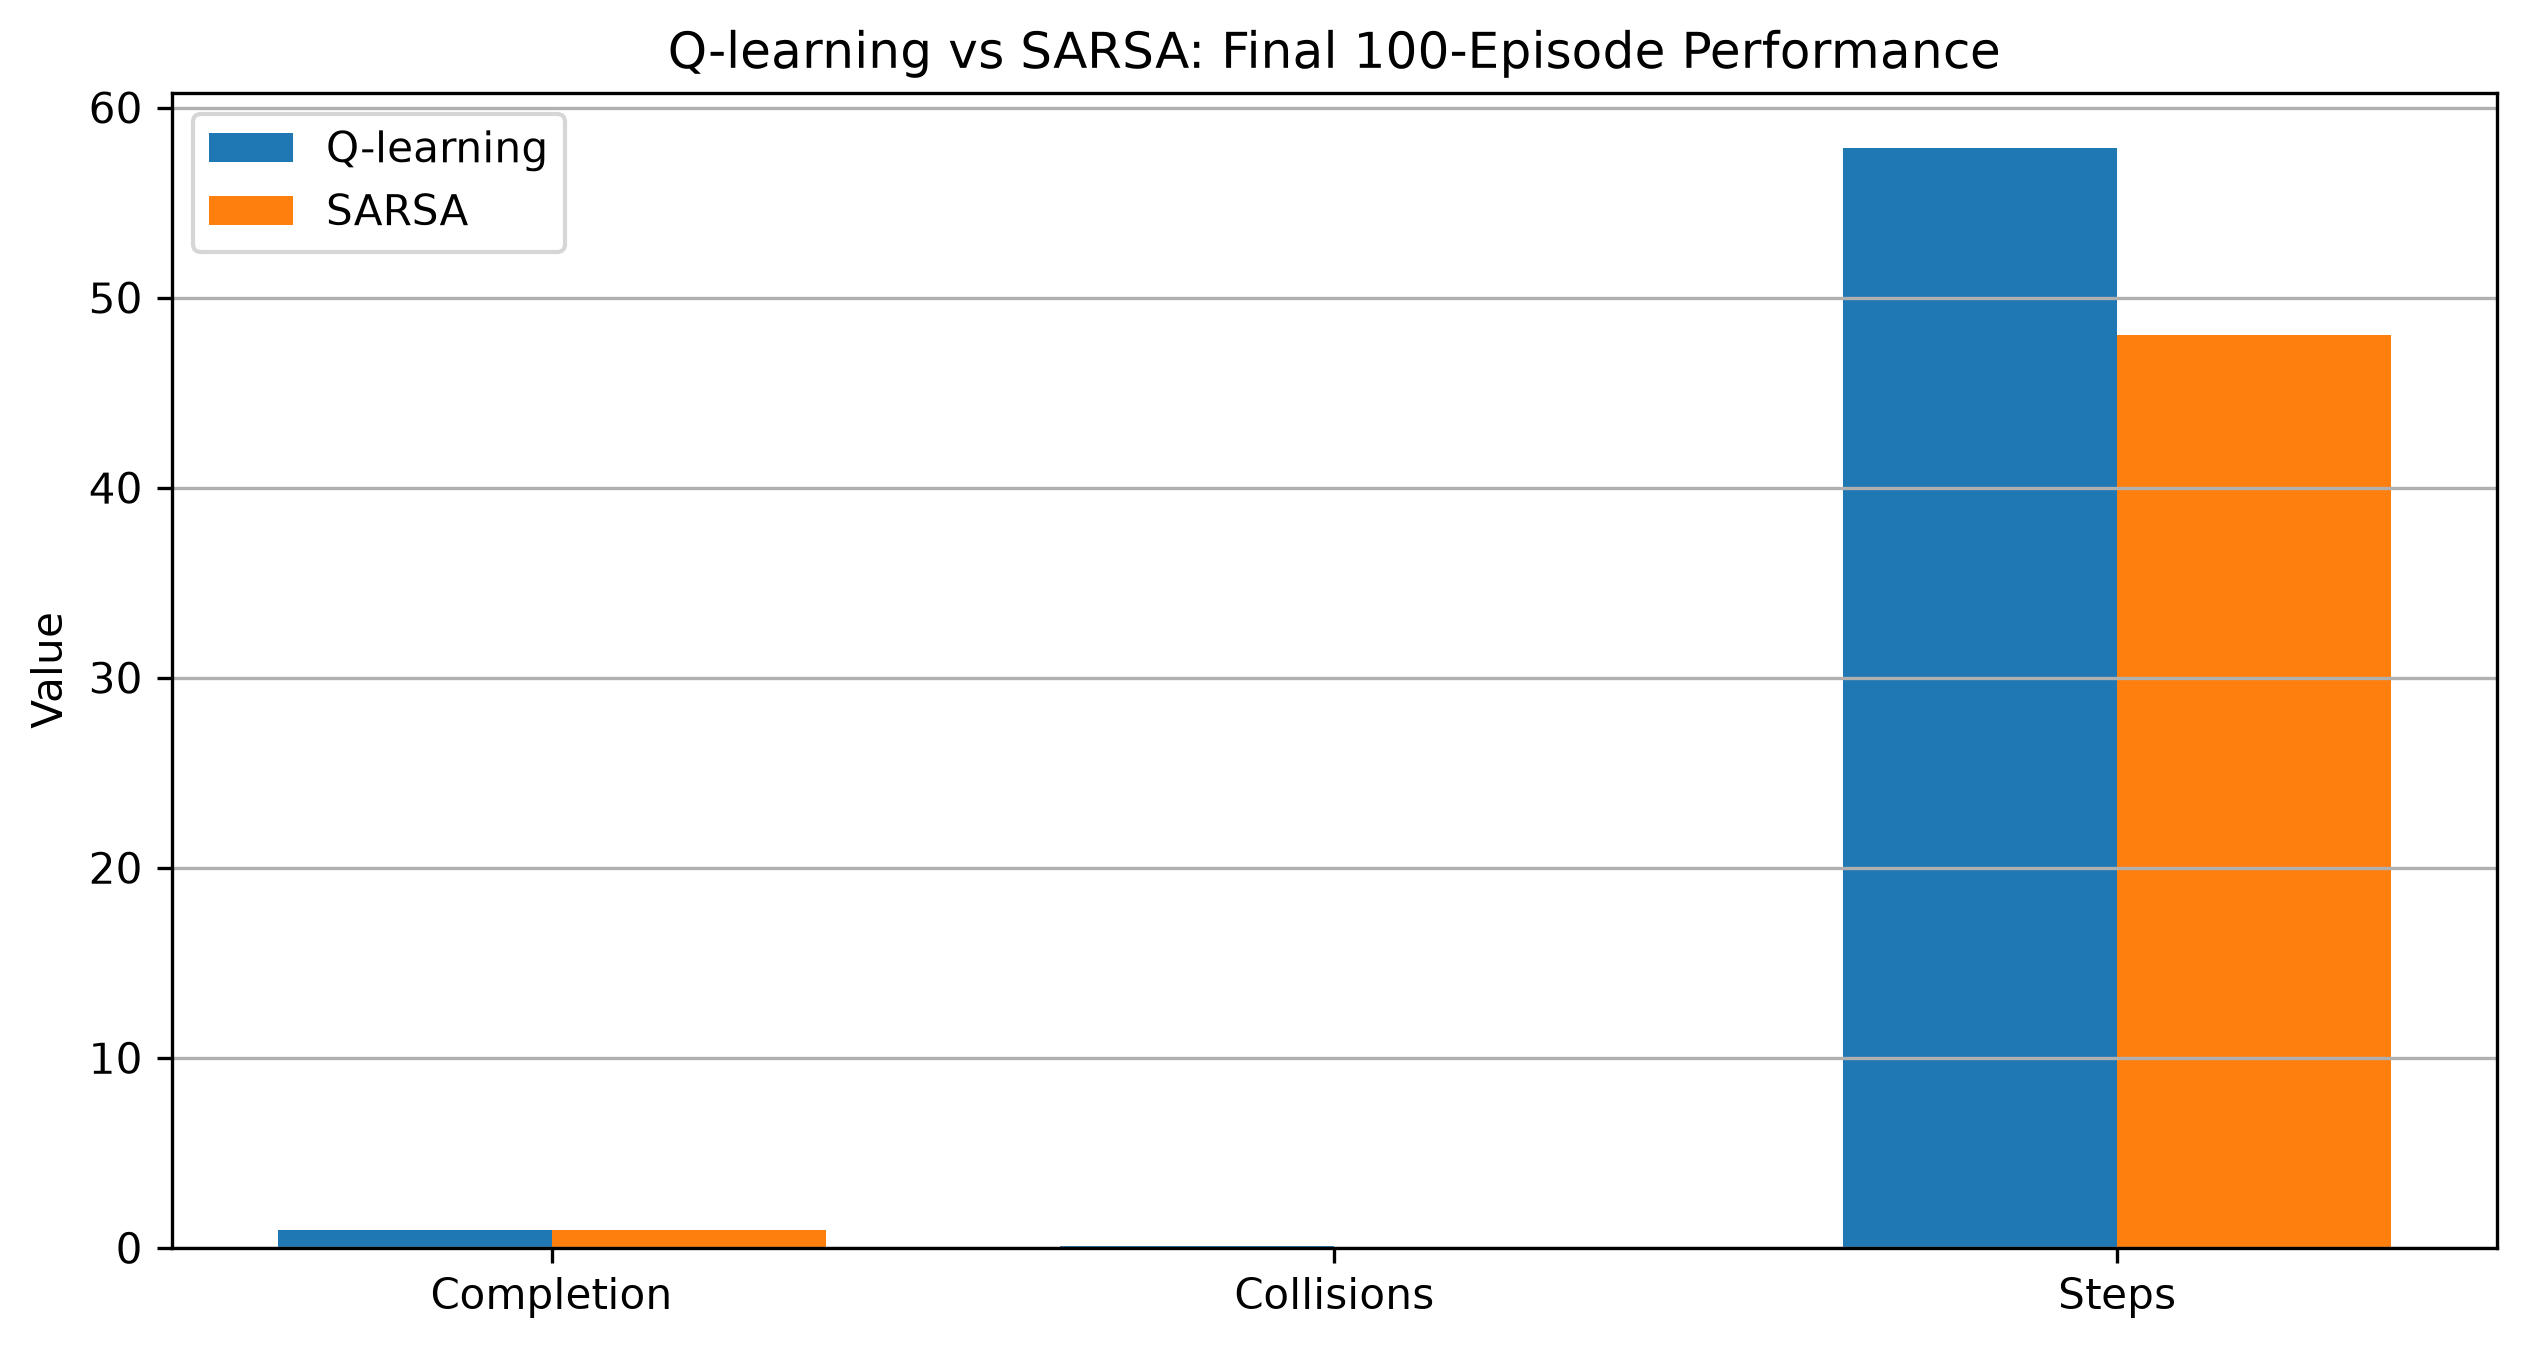

In [13]:
from IPython.display import Image, display

display(Image(filename=str(comparison_image)))

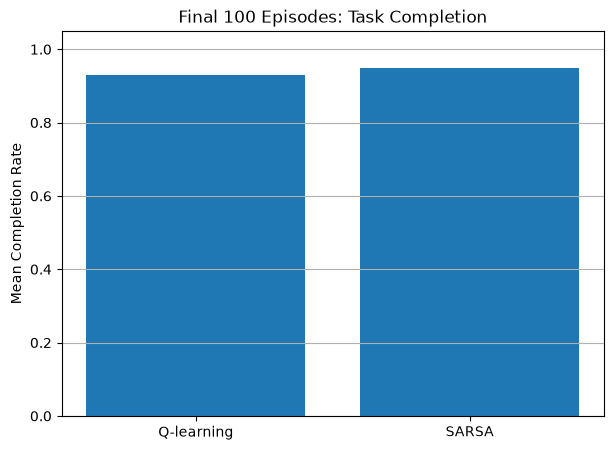

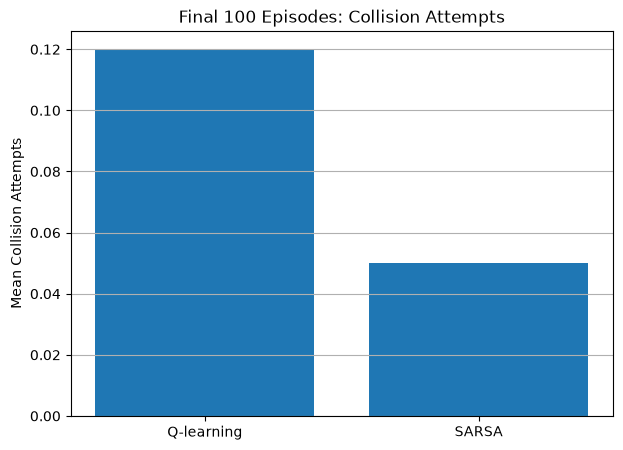

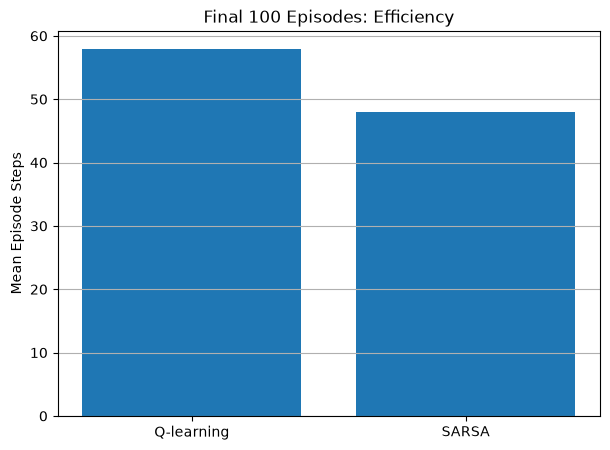

Saved figures:
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\docs\assets\completion_rate_comparison.png
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\docs\assets\collision_comparison.png
C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0\docs\assets\steps_comparison.png


In [14]:
import matplotlib.pyplot as plt

figures_dir = project_root / "docs" / "assets"
figures_dir.mkdir(parents=True, exist_ok=True)

algorithms = summary["Algorithm"].tolist()

completion_values = summary["Mean completion - last 100 episodes"].tolist()
collision_values = summary["Mean collisions - last 100 episodes"].tolist()
step_values = summary["Mean steps - last 100 episodes"].tolist()

# Figure 1: completion rate
plt.figure(figsize=(7, 5))
plt.bar(algorithms, completion_values)
plt.ylabel("Mean Completion Rate")
plt.title("Final 100 Episodes: Task Completion")
plt.ylim(0, 1.05)
plt.grid(axis="y")
completion_path = figures_dir / "completion_rate_comparison.png"
plt.savefig(completion_path, dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: collisions
plt.figure(figsize=(7, 5))
plt.bar(algorithms, collision_values)
plt.ylabel("Mean Collision Attempts")
plt.title("Final 100 Episodes: Collision Attempts")
plt.grid(axis="y")
collision_path = figures_dir / "collision_comparison.png"
plt.savefig(collision_path, dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: steps
plt.figure(figsize=(7, 5))
plt.bar(algorithms, step_values)
plt.ylabel("Mean Episode Steps")
plt.title("Final 100 Episodes: Efficiency")
plt.grid(axis="y")
steps_path = figures_dir / "steps_comparison.png"
plt.savefig(steps_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(completion_path)
print(collision_path)
print(steps_path)

In [15]:
from pathlib import Path

artifacts_dir = project_root / "artifacts"
assets_dir = project_root / "docs" / "assets"

print("Artifacts:")
for item in sorted(artifacts_dir.iterdir()):
    print("-", item.name)

print("\nAssets:")
for item in sorted(assets_dir.iterdir()):
    print("-", item.name)

Artifacts:
- q_learning.csv
- q_learning.json
- q_learning_vs_sarsa_summary.csv
- sarsa.csv
- sarsa.json
- tabular_benchmark.csv
- tabular_benchmark.summary.json

Assets:
- collision_comparison.png
- completion_rate_comparison.png
- q_learning_curve.png
- q_learning_vs_sarsa_summary.png
- steps_comparison.png
- warehouse_layout.png


In [1]:
from pathlib import Path

project_root = Path.cwd().parent

print("Project root:", project_root)
print("Artifacts exists:", (project_root / "artifacts").exists())
print("Assets exists:", (project_root / "docs" / "assets").exists())

print("\nArtifacts:")
for item in sorted((project_root / "artifacts").iterdir()):
    print("-", item.name)

print("\nAssets:")
for item in sorted((project_root / "docs" / "assets").iterdir()):
    print("-", item.name)

Project root: C:\Users\mazya\Documents\FleetRL_Warehouse_v0.1.0
Artifacts exists: True
Assets exists: True

Artifacts:
- a2c_smoke_test.zip
- ddpg_smoke_test.zip
- ppo_smoke_test.zip
- q_learning.csv
- q_learning.json
- q_learning_vs_sarsa_summary.csv
- sac_smoke_test.zip
- sarsa.csv
- sarsa.json
- tabular_benchmark.csv
- tabular_benchmark.summary.json

Assets:
- collision_comparison.png
- completion_rate_comparison.png
- q_learning_curve.png
- q_learning_vs_sarsa_summary.png
- steps_comparison.png
- warehouse_layout.png
